In [ ]:
import pandas as pd

# Load and explore the dataset.
df = pd.read_csv('fake_or_real_news.csv')

print(df.head())
print(df.info())

print(df['label'].value_counts())

                                                text label Unnamed: 2  \
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE        NaN   
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE        NaN   
2  U.S. Secretary of State John F. Kerry said Mon...  REAL        NaN   
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE        NaN   
4  It's primary day in New York and front-runners...  REAL        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9  ... Unnamed: 129 Unnamed: 130 Unnamed: 131 Unnamed: 132  \
0        NaN  ...          NaN          NaN          NaN     

C:\Users\WALTON\AppData\Local\Temp\ipykernel_11592\1566111790.py:4: DtypeWarning: Columns (22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fake_or_real_news.csv')


In [2]:
#. Preprocess the data if required (handle missing values, encode categorical variables, etc.).
from sklearn.feature_extraction.text import TfidfVectorizer

clean_df = df[df['label'].isin(['REAL', 'FAKE'])][['text', 'label']]

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)


In [3]:
# . Split the data into training and testing sets.
from sklearn.model_selection import train_test_split

X = clean_df['text']
y = clean_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)

In [ ]:
# Build a Naive Bayes model using the training data.
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(tfidf_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [5]:
# Evaluate the model's performance using appropriate metrics (e.g., accuracy, confusion matrix).
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = nb_classifier.predict(tfidf_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8487727632620744
              precision    recall  f1-score   support

        FAKE       0.97      0.71      0.82       616
        REAL       0.78      0.98      0.87       647

    accuracy                           0.85      1263
   macro avg       0.88      0.85      0.85      1263
weighted avg       0.87      0.85      0.85      1263



Overall Accuracy: 84.88%

Detailed Performance Report:
              precision    recall  f1-score   support

        FAKE       0.97      0.71      0.82       616
        REAL       0.78      0.98      0.87       647

    accuracy                           0.85      1263
   macro avg       0.88      0.85      0.85      1263
weighted avg       0.87      0.85      0.85      1263



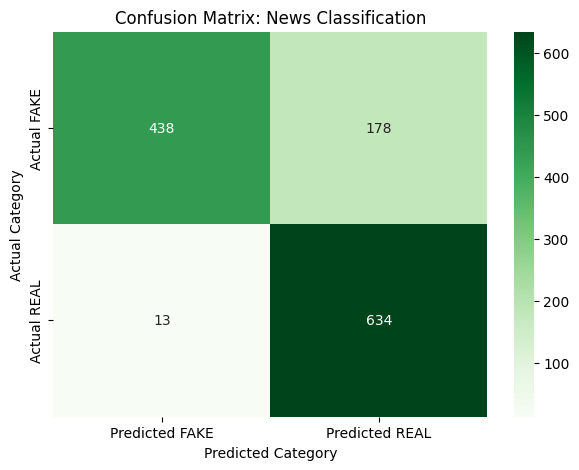

In [6]:
# Interpret the results and provide a brief summary of findings.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=['FAKE', 'REAL'])

print(f"Overall Accuracy: {accuracy:.2%}")
print("\nDetailed Performance Report:")
print(report)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted FAKE', 'Predicted REAL'],
            yticklabels=['Actual FAKE', 'Actual REAL'])
plt.title('Confusion Matrix: News Classification')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.savefig('evaluation_results.png')